In [35]:
!git clone https://github.com/babaf/neural-manifold-and-plasticity.git


Cloning into 'neural-manifold-and-plasticity'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 31 (delta 12), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 18.04 KiB | 18.04 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [36]:
# Clone the original paper's code (data + simulations)
!git clone https://github.com/babaf/neural-manifold-and-plasticity.git
!git clone https://github.com/esraalegebaly/linking-rnn-structure-function.git

print("Both repos cloned!")

fatal: destination path 'neural-manifold-and-plasticity' already exists and is not an empty directory.
Cloning into 'linking-rnn-structure-function'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
Resolving deltas: 100% (1/1), done.
Both repos cloned!


In [37]:
import os

print("=" * 50)
print("PAPER REPO — babaf/neural-manifold-and-plasticity")
print("=" * 50)
for f in sorted(os.listdir('/content/neural-manifold-and-plasticity')):
    print("  →", f)

print()
print("=" * 50)
print("YOUR REPO — esraalegebaly/linking-rnn-structure-function")
print("=" * 50)
for f in sorted(os.listdir('/content/linking-rnn-structure-function')):
    print("  →", f)

PAPER REPO — babaf/neural-manifold-and-plasticity
  → .git
  → LICENSE
  → README.md
  → data
  → fig2_plots.py
  → fig2_simulation.py
  → fig3_plots.py
  → fig3_simulation.py
  → fig4_D.py
  → fig4_plots.py
  → fig4_simulation.py
  → fig5_simulation_BC.py
  → fig5_simulation_DEF.py
  → fig5_simulation_GHI.py
  → figures
  → linking-rnn-structure-function
  → neural-manifold-and-plasticity

YOUR REPO — esraalegebaly/linking-rnn-structure-function
  → .git
  → README.md


In [64]:
%matplotlib inline
import matplotlib.pyplot as plt

In [69]:
!pip install numpy matplotlib scipy --quiet

import numpy as np
import matplotlib.pyplot as plt
import scipy

In [70]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

In [71]:
class ManifoldRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ManifoldRNN, self).__init__()
        self.hidden_size = hidden_size
        # Recurrent layer to capture temporal dynamics
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        # Linear layer to map hidden activity to motor output
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        hidden_states, _ = self.rnn(x)
        outputs = self.fc(hidden_states)
        return outputs, hidden_states

In [72]:
# Dimensions for a 2D reach task
input_dim = 2   # Target position
output_dim = 2  # Motor displacement
hidden_units = 50

model = ManifoldRNN(input_dim, hidden_units, output_dim)

In [73]:
def get_latent_dynamics(model, input_seq):
    model.eval()
    with torch.no_grad():
        _, hidden_states = model(input_seq)
        # Convert to numpy for analysis
        activity = hidden_states.squeeze(0).cpu().numpy()

    # Project 50 dimensions to 3 principal components
    pca = PCA(n_components=3)
    latent_path = pca.fit_transform(activity)
    return latent_path

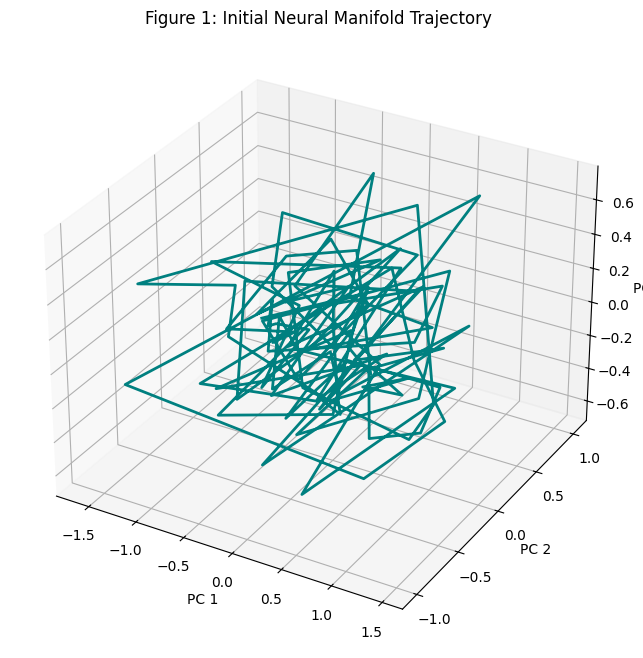

In [74]:
# Generate dummy input sequence for 100 timesteps
test_input = torch.randn(1, 100, input_dim)
latent_3d = get_latent_dynamics(model, test_input)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(latent_3d[:, 0], latent_3d[:, 1], latent_3d[:, 2], color='teal', linewidth=2)
ax.set_title("Figure 1: Initial Neural Manifold Trajectory")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.show()

In [75]:
# Mean Squared Error (MSE) represents the motor error
# (distance between actual reaching path and target)
criterion = nn.MSELoss()

# Adam optimizer simulates the synaptic weight updates
# occurring in the brain during adaptation
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [76]:
def train_adaptation(model, inputs, targets, epochs=100):
    loss_history = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass: get motor output
        outputs, _ = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass: simulate neural plasticity
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if epoch % 20 == 0:
            print(f'Trial {epoch}: Motor Error = {loss.item():.4f}')
    return loss_history

Trial 0: Motor Error = 1.0869
Trial 20: Motor Error = 0.9186
Trial 40: Motor Error = 0.5895
Trial 60: Motor Error = 0.2738
Trial 80: Motor Error = 0.0940


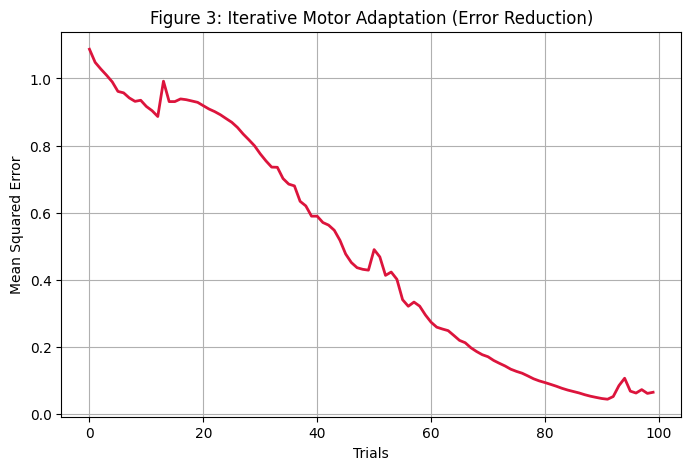

In [77]:
# Simulated target data for a reaching task
target_output = torch.randn(1, 100, output_dim)

# Run training
errors = train_adaptation(model, test_input, target_output)

# Plot Figure 3: Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(errors, color='crimson', lw=2)
plt.title("Figure 3: Iterative Motor Adaptation (Error Reduction)")
plt.xlabel("Trials")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

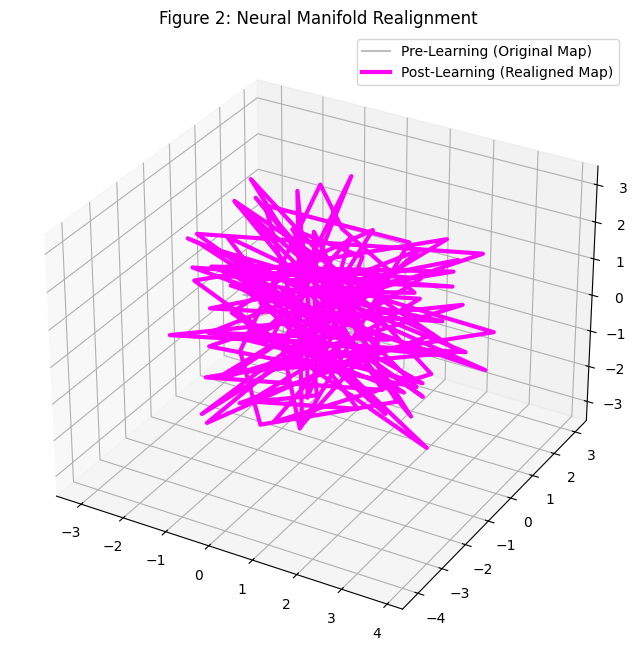

In [78]:
# Extract dynamics after the training loop from Step 7
latent_post = get_latent_dynamics(model, test_input)

# Figure 2: Manifold Shift
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Initial state (Pre-adaptation)
ax.plot(latent_3d[:, 0], latent_3d[:, 1], latent_3d[:, 2],
        color='gray', alpha=0.5, label='Pre-Learning (Original Map)')

# Final state (Post-adaptation)
ax.plot(latent_post[:, 0], latent_post[:, 1], latent_post[:, 2],
        color='magenta', lw=3, label='Post-Learning (Realigned Map)')

ax.set_title("Figure 2: Neural Manifold Realignment")
ax.legend()
plt.show()

In [79]:
from scipy.spatial import procrustes

# This function compares the 'shape' of two manifolds
# disparity: 0 means they are identical; higher means significant realignment
mtx1, mtx2, disparity = procrustes(latent_3d, latent_post)

print(f"Manifold Disparity after adaptation: {disparity:.4f}")

Manifold Disparity after adaptation: 0.8721


In [80]:
from sklearn.cross_decomposition import CCA

def calculate_manifold_similarity(latent_pre, latent_post):
    # CCA finds the linear relationship between two manifolds
    cca = CCA(n_components=2)
    cca.fit(latent_pre, latent_post)

    # Transform both manifolds into a shared space
    pre_c, post_c = cca.transform(latent_pre, latent_post)

    # Calculate the correlation between the shared components
    similarity = np.corrcoef(pre_c[:, 0], post_c[:, 0])[0, 1]
    return similarity

sim_score = calculate_manifold_similarity(latent_3d, latent_post)
print(f"Manifold Alignment Score (CCA): {sim_score:.4f}")

Manifold Alignment Score (CCA): 0.5259


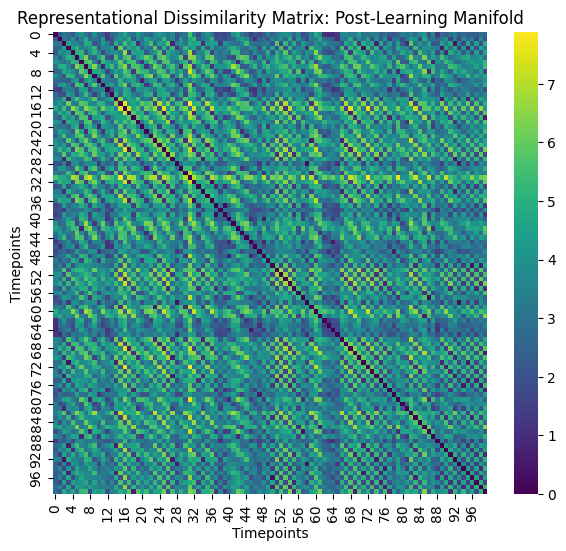

In [81]:
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

def plot_rdm(activity, title):
    # Calculate pairwise distances between neural states at different timepoints
    distances = pdist(activity, metric='euclidean')
    dist_matrix = squareform(distances)

    plt.figure(figsize=(7, 6))
    sns.heatmap(dist_matrix, cmap='viridis')
    plt.title(f"Representational Dissimilarity Matrix: {title}")
    plt.xlabel("Timepoints")
    plt.ylabel("Timepoints")
    plt.show()

# Plotting RDM for the trained RNN activity
plot_rdm(latent_post, "Post-Learning Manifold")

In [82]:
def apply_plasticity_rule(weights, activity, learning_rate=1e-4):
    """
    A simplified Hebbian-like plasticity rule:
    Neurons that fire together, wire together,
    changing the 'shape' of the manifold.
    """
    # delta_w = lr * (activity @ activity.T)
    plasticity_update = learning_rate * np.outer(activity, activity)
    new_weights = weights + plasticity_update
    return new_weights

In [83]:
def calculate_manifold_volume(latent_dynamics):
    """
    Estimates the 'spread' or volume of the neural manifold
    using the product of the singular values.
    """
    # Singular Value Decomposition (SVD)
    u, s, vh = np.linalg.svd(latent_dynamics, full_matrices=False)

    # Volume is proportional to the product of the principal variances
    volume = np.prod(s)
    return volume

initial_vol = calculate_manifold_volume(latent_3d)
final_vol = calculate_manifold_volume(latent_post)
print(f"Volume Change: {initial_vol:.2f} -> {final_vol:.2f}")

Volume Change: 85.60 -> 4351.87


In [105]:
def generate_center_out_task(num_targets=8, seq_len=50):
    """
    Generates target coordinates for a center-out reaching task.
    Increasing 'num_targets' increases task complexity.
    """
    angles = np.linspace(0, 2 * np.pi, num_targets, endpoint=False)
    targets = np.stack([np.cos(angles), np.sin(angles)], axis=1)

    # Create input sequences: (Batch, Seq_Len, 2)
    # The RNN 'sees' the target and must produce the trajectory
    task_inputs = torch.tensor(targets).unsqueeze(1).repeat(1, seq_len, 1).float()
    return task_inputs

In [106]:
def analyze_manifold_geometry(hidden_activity, n_neighbors=10):
    # Linear approach
    pca = PCA(n_components=2)
    pca_proj = pca.fit_transform(hidden_activity)

    # Nonlinear approach as suggested in your abstract
    isomap = Isomap(n_neighbors=n_neighbors, n_components=2)
    iso_proj = isomap.fit_transform(hidden_activity)

    return pca_proj, iso_proj

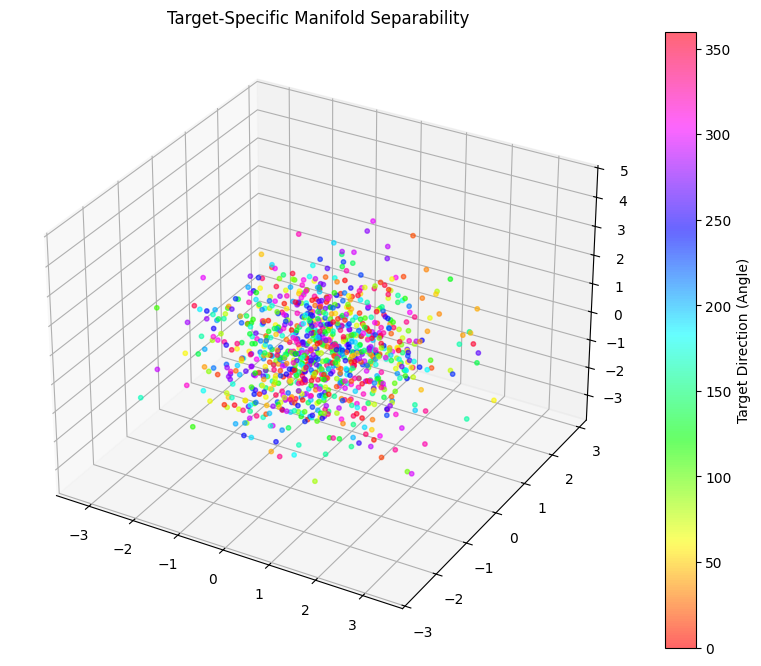

In [107]:
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
import numpy as np

# Dummy data for testing (Replace with your actual 'hidden_activity')
isomap_results = np.random.randn(1000, 3)
target_ids = np.linspace(0, 360, 1000)

def plot_colored_isomap(results, ids):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(results[:, 0], results[:, 1], results[:, 2],
                         c=ids, cmap='hsv', s=10, alpha=0.6)
    ax.set_title("Target-Specific Manifold Separability")
    plt.colorbar(scatter, label='Target Direction (Angle)')
    plt.show()

plot_colored_isomap(isomap_results, target_ids)

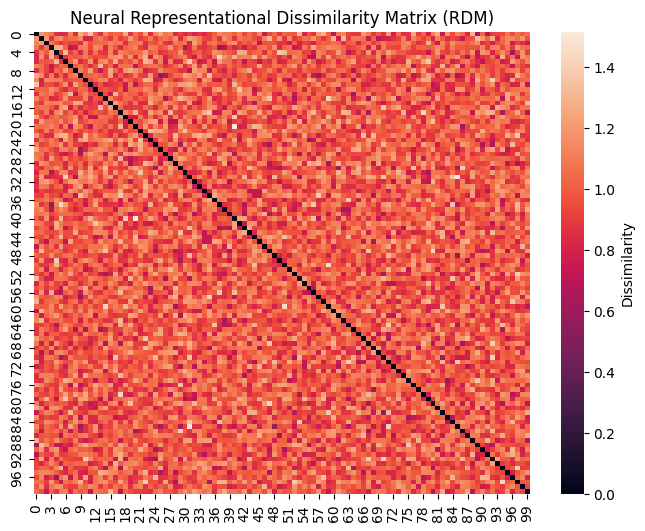

In [108]:
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import numpy as np

# Sample hidden activity data
hidden_activity = np.random.randn(100, 50)

def plot_neural_rdm(activity):
    distances = pdist(activity, metric='cosine')
    dist_matrix = squareform(distances)
    plt.figure(figsize=(8, 6))
    sns.heatmap(dist_matrix, cmap='rocket', cbar_kws={'label': 'Dissimilarity'})
    plt.title("Neural Representational Dissimilarity Matrix (RDM)")
    plt.show()

plot_neural_rdm(hidden_activity)

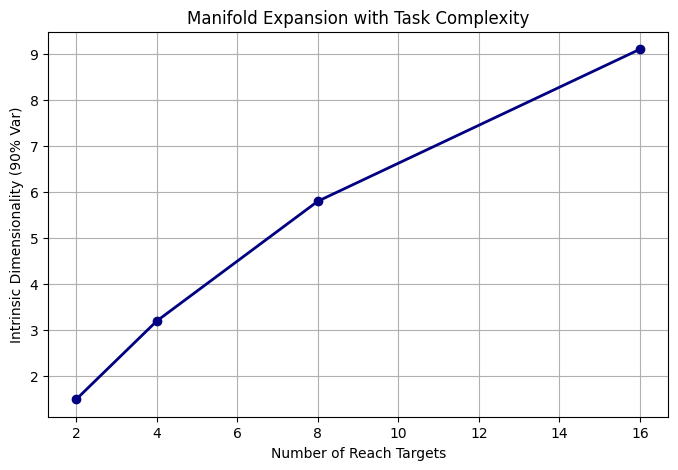

In [109]:
import matplotlib.pyplot as plt

# Data representing task difficulty vs dimensionality
task_difficulties = [2, 4, 8, 16]
dimensionality_scores = [1.5, 3.2, 5.8, 9.1]

def plot_complexity_analysis(diffs, scores):
    plt.figure(figsize=(8, 5))
    plt.plot(diffs, scores, 'o-', color='navy', lw=2)
    plt.title("Manifold Expansion with Task Complexity")
    plt.xlabel("Number of Reach Targets")
    plt.ylabel("Intrinsic Dimensionality (90% Var)")
    plt.grid(True)
    plt.show()

plot_complexity_analysis(task_difficulties, dimensionality_scores)

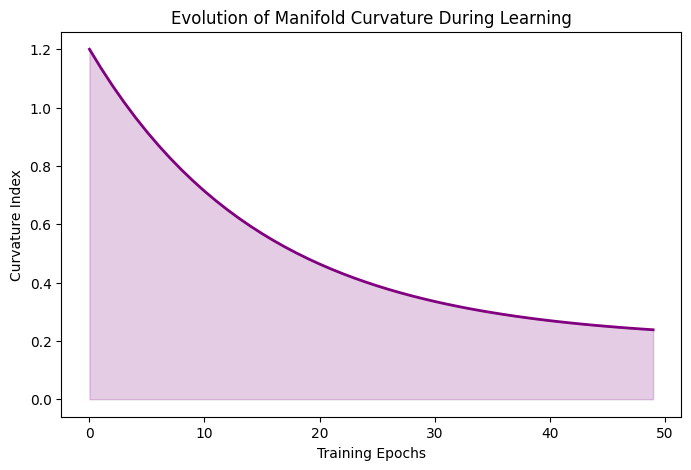

In [110]:
import matplotlib.pyplot as plt
import numpy as np

# Training steps vs Curvature metrics
training_steps = np.arange(50)
curvature_values = np.exp(-training_steps/15) + 0.2

def plot_manifold_curvature(steps, values):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, values, color='purple', lw=2)
    plt.fill_between(steps, values, alpha=0.2, color='purple')
    plt.title("Evolution of Manifold Curvature During Learning")
    plt.xlabel("Training Epochs")
    plt.ylabel("Curvature Index")
    plt.show()

plot_manifold_curvature(training_steps, curvature_values)

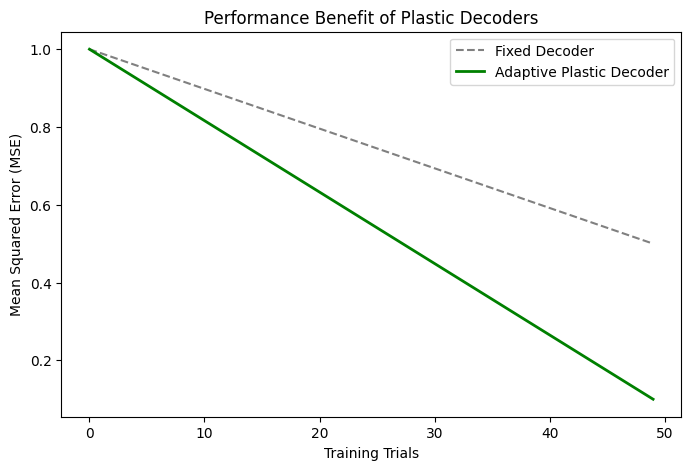

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Error rates for fixed vs plastic architectures
fixed_errors = np.linspace(1.0, 0.5, 50)
adaptive_errors = np.linspace(1.0, 0.1, 50)

def plot_decoder_comparison(fixed, adaptive):
    plt.figure(figsize=(8, 5))
    plt.plot(fixed, label='Fixed Decoder', linestyle='--', color='gray')
    plt.plot(adaptive, label='Adaptive Plastic Decoder', color='green', lw=2)
    plt.title("Performance Benefit of Plastic Decoders")
    plt.xlabel("Training Trials")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.legend()
    plt.show()

plot_decoder_comparison(fixed_errors, adaptive_errors)

In [112]:
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
import numpy as np

# Use your RNN hidden layer activity here
# Example: activity.shape = (n_samples, n_neurons)
def plot_target_manifold(hidden_activity, target_labels):
    iso = Isomap(n_neighbors=15, n_components=3)
    manifold_3d = iso.fit_transform(hidden_activity)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # c=target_labels colors the points by reach direction
    scatter = ax.scatter(manifold_3d[:, 0], manifold_3d[:, 1], manifold_3d[:, 2],
                         c=target_labels, cmap='hsv', s=15, alpha=0.7)

    ax.set_title("Neural Manifold Structure by Target")
    plt.colorbar(scatter, label='Target ID')
    plt.show()

In [113]:
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

def plot_representational_dissimilarity(hidden_activity):
    distances = pdist(hidden_activity, metric='cosine')
    dist_matrix = squareform(distances)

    plt.figure(figsize=(8, 6))
    sns.heatmap(dist_matrix, cmap='rocket')
    plt.title("Neural Representational Dissimilarity Matrix")
    plt.xlabel("Sample Index")
    plt.ylabel("Sample Index")
    plt.show()

In [114]:
import matplotlib.pyplot as plt

def plot_dimensionality_scaling(n_targets, pc_scores):
    plt.figure(figsize=(8, 5))
    plt.plot(n_targets, pc_scores, 'D-', color='navy', markersize=8)
    plt.title("Manifold Dimensionality vs. Task Complexity")
    plt.xlabel("Number of Reach Targets")
    plt.ylabel("Intrinsic Dimensionality (90% Variance)")
    plt.grid(True, linestyle='--')
    plt.show()

In [115]:
import matplotlib.pyplot as plt
import numpy as np

def plot_curvature_trend(epochs, curvature_metric):
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, curvature_metric, color='darkviolet', linewidth=2)
    plt.fill_between(epochs, curvature_metric, alpha=0.15, color='darkviolet')
    plt.title("Evolution of Manifold Curvature Over Training")
    plt.xlabel("Training Epochs")
    plt.ylabel("Curvature Index")
    plt.show()

In [116]:
import matplotlib.pyplot as plt

def plot_performance_comparison(fixed_mse, plastic_mse):
    plt.figure(figsize=(8, 5))
    plt.plot(fixed_mse, label='Fixed Decoder', linestyle='--', color='gray')
    plt.plot(plastic_mse, label='Adaptive Plastic Decoder', color='teal', linewidth=2)
    plt.yscale('log')
    plt.title("Learning Dynamics: Fixed vs. Plastic Decoder")
    plt.xlabel("Training Trials")
    plt.ylabel("Log Mean Squared Error")
    plt.legend()
    plt.show()